In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style("whitegrid")

### Why Seaborn?

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Seaborn Roadmap

Types of Functions

- Figure Level
- Axis Level

Main Classification

- Relational Plot
- Distribution Plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

### 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

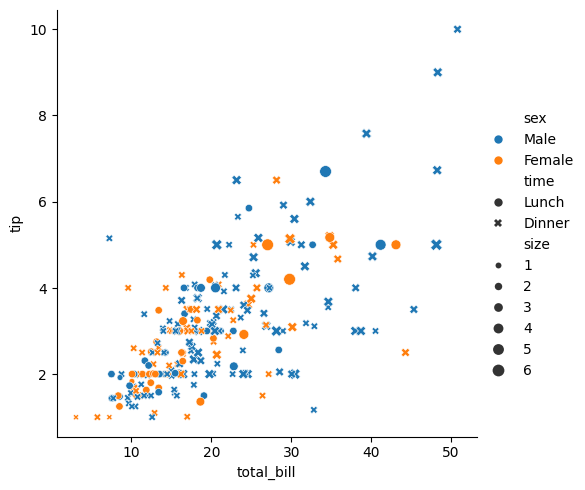

In [3]:
# scatter plot -> axes level fn -> generally rectangular img

tips = sns.load_dataset('tips')

# sns.scatterplot(data = tips,x='total_bill',y='tip')


# scatter plot -> figure level fn -> generally square img -> recommended by seaborn team as using 1 fig you can create many axes

# all this hue,size and style are available in scatterplot()

sns.relplot(data = tips,x='total_bill',y='tip',kind='scatter',hue='sex',style='time',size='size')

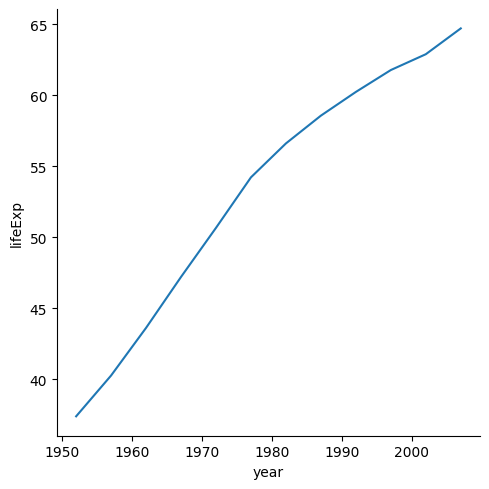

In [4]:
# lineplot

gap = px.data.gapminder()
gap

# life expectency of india from year 1952 and 2007

india_data = gap[(gap['country'] == 'India') & (gap['year'] >= 1952)]

sns.relplot(data = india_data,x = 'year', y = 'lifeExp' , kind='line')

<Axes: xlabel='year', ylabel='lifeExp'>

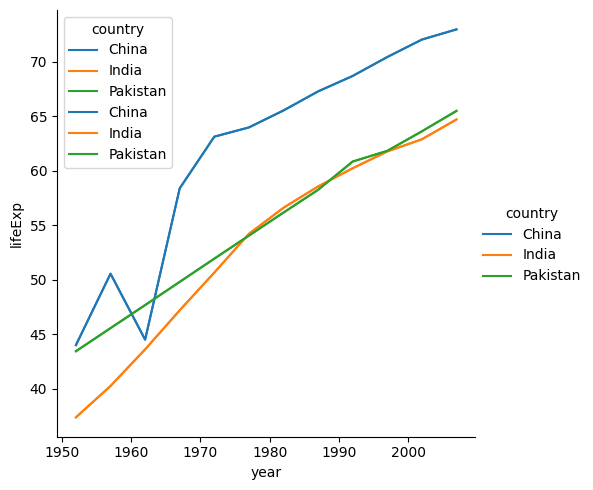

In [5]:
# hue and style

temp = gap[gap['country'].isin(['India','China','Pakistan'])]
temp

# 2nd diff b/w fig level and axes level

sns.relplot(kind = 'line', data = temp, x = 'year', y = 'lifeExp', hue = 'country') # -> legend outside graph
sns.lineplot( data = temp, x = 'year', y = 'lifeExp', hue = 'country')  # -> legend inside graph

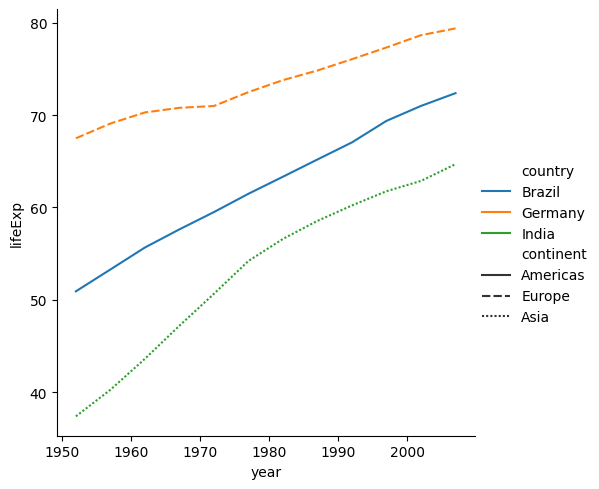

In [6]:
countries = gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.relplot(data = countries, x = 'year', y = 'lifeExp' , kind = 'line', hue = 'country', style = 'continent')


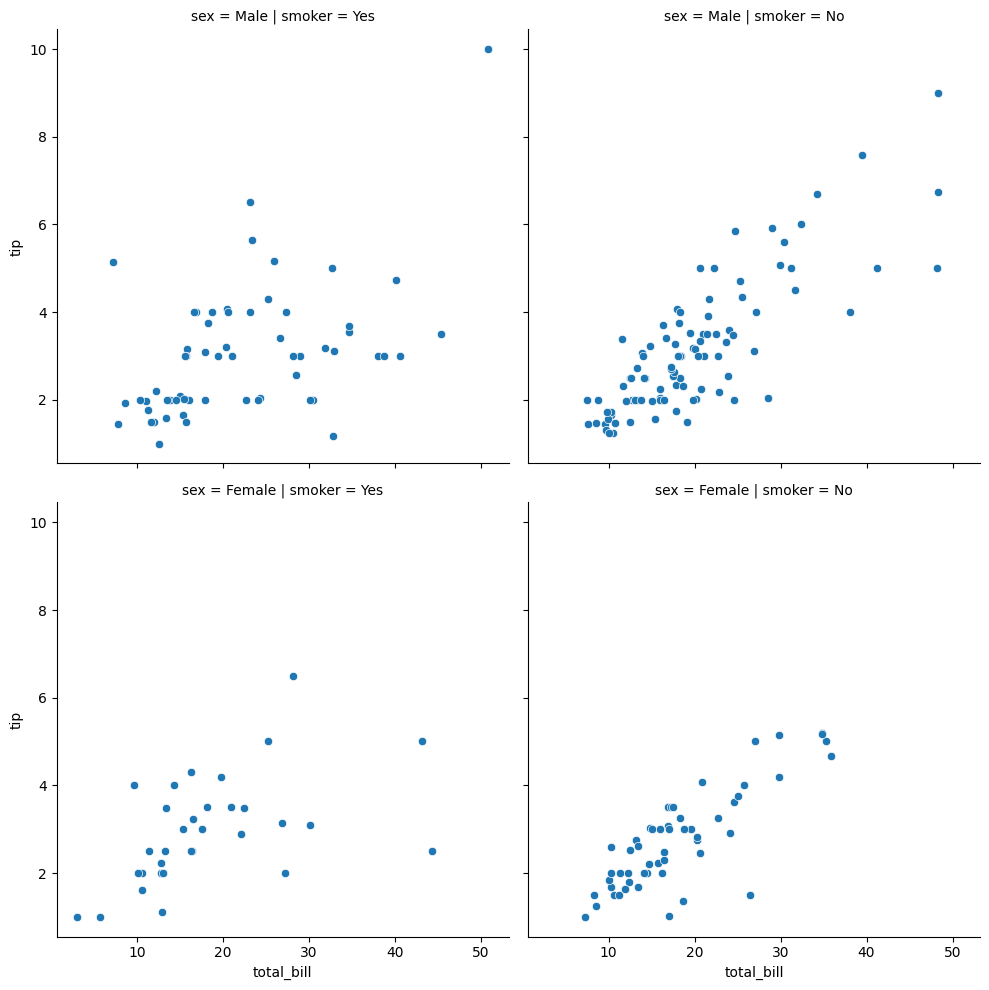

In [8]:
# facet plot -> will only work with figure level fn not axes level fn

tips
sns.relplot(kind = 'scatter', data = tips, x = 'total_bill', y = 'tip', col = 'smoker', row = 'sex')

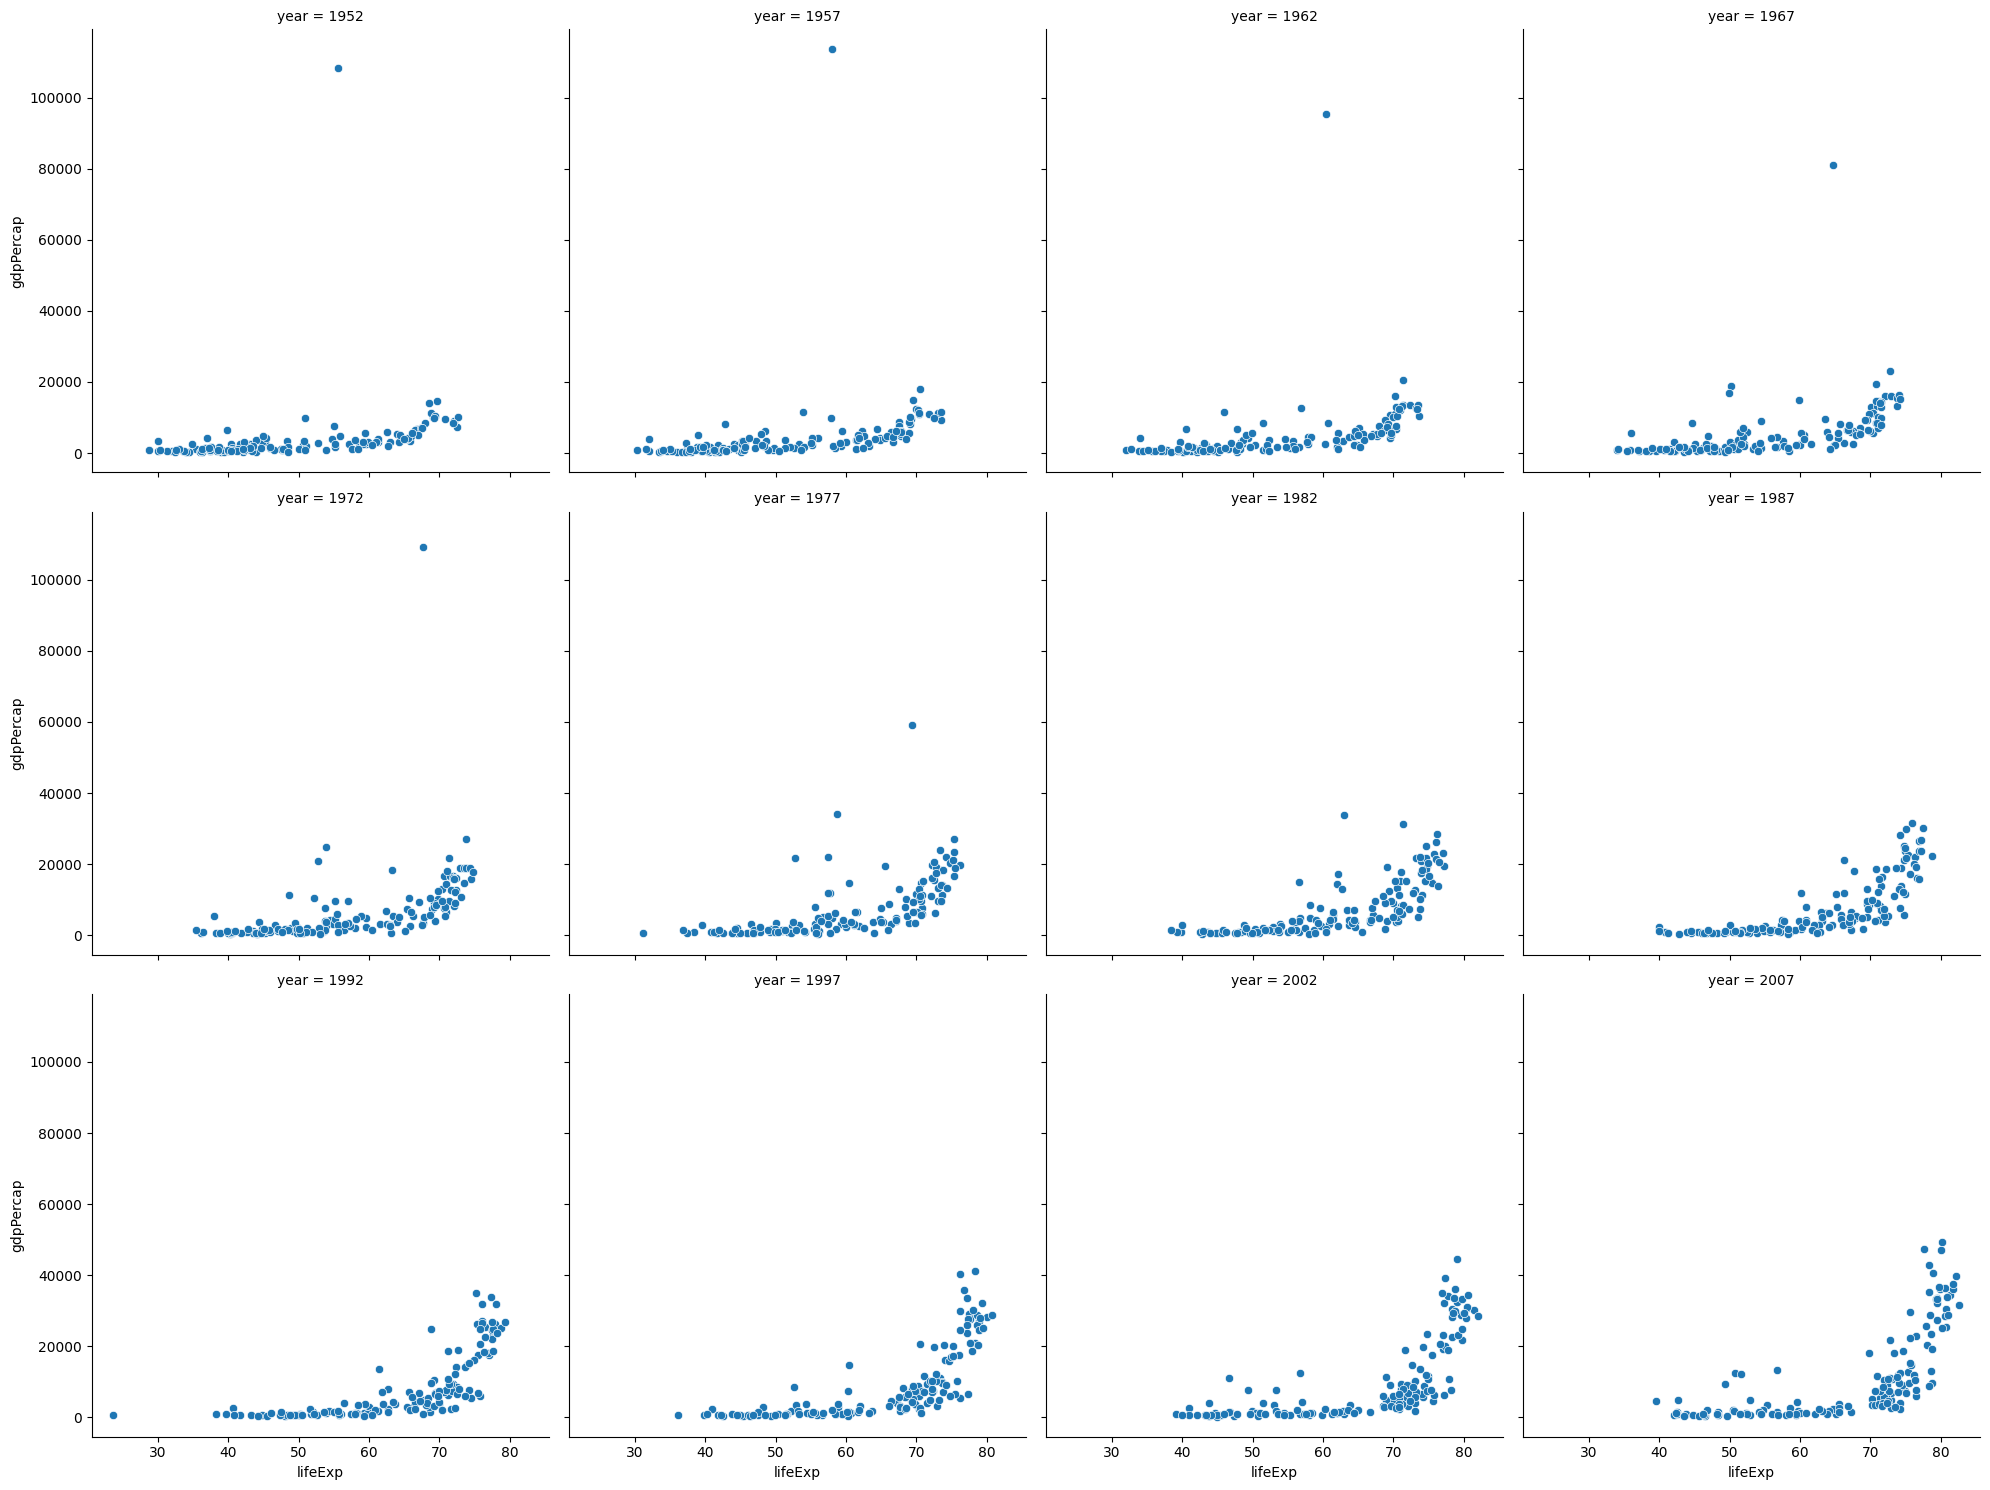

In [9]:
# col wrap

gap
# for each year lifeExp v/s gdpPercap

sns.relplot(kind = 'scatter', data = gap, x = 'lifeExp', y = 'gdpPercap', col = 'year', col_wrap=4)

### 2. Distribution Plots

- used for univariate analysis
- used to find out the distribution
- Range of the observation
- Central Tendency
- is the data bimodal?
- Are there outliers?

Plots under distribution plot

- histplot
- kdeplot
- rugplot

In [ ]:
# figure level -> displot (one fn can plot all three kind of distribution plots)
# axes level -> kdeplot -> histplot -> rugplot

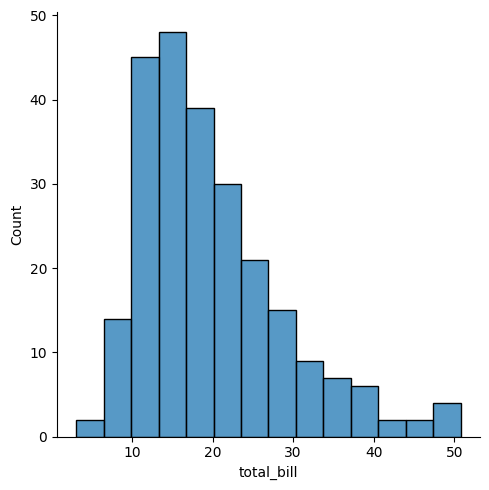

In [11]:
# plotting univariate histogram

# analysis on tips total_bill column

sns.displot(kind = 'hist', data = tips['total_bill'])

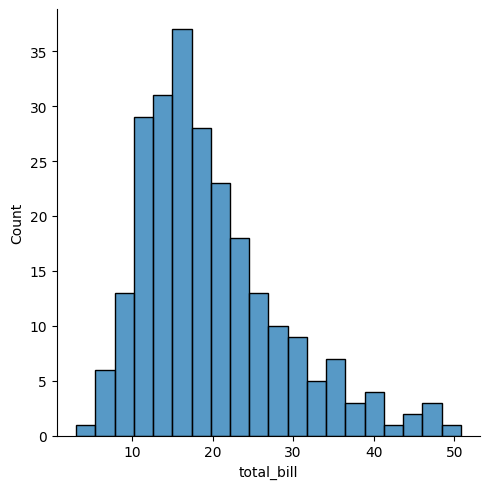

In [12]:
# bins parameter

sns.displot(kind = 'hist', data = tips['total_bill'],bins = 20)


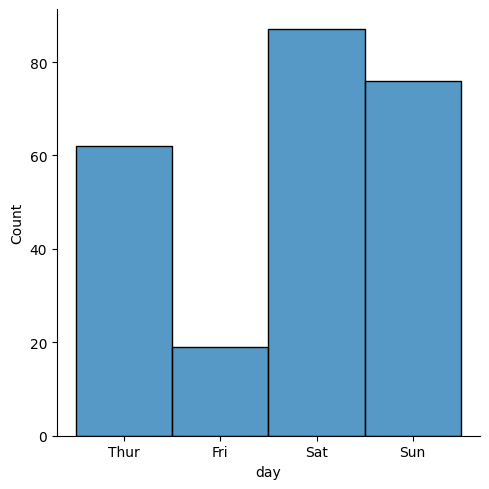

In [14]:
# generally histogram is plotted on numerical data but here we can plot on categorical data

sns.displot(kind = 'hist', data = tips, x = 'day')


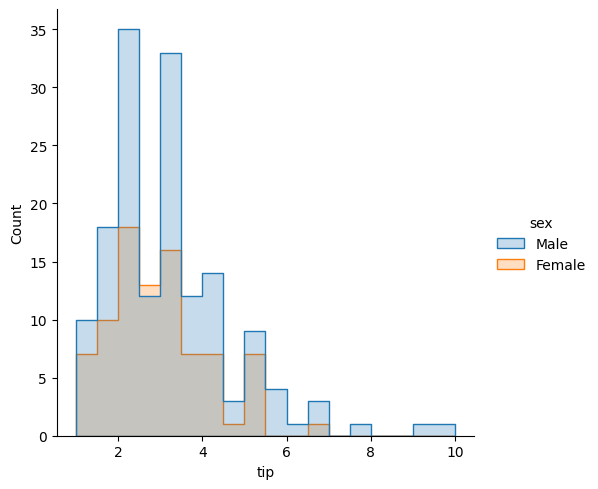

In [18]:
# hue parameter

sns.displot(kind = 'hist', data = tips,x = 'tip',hue = 'sex',element='step')


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


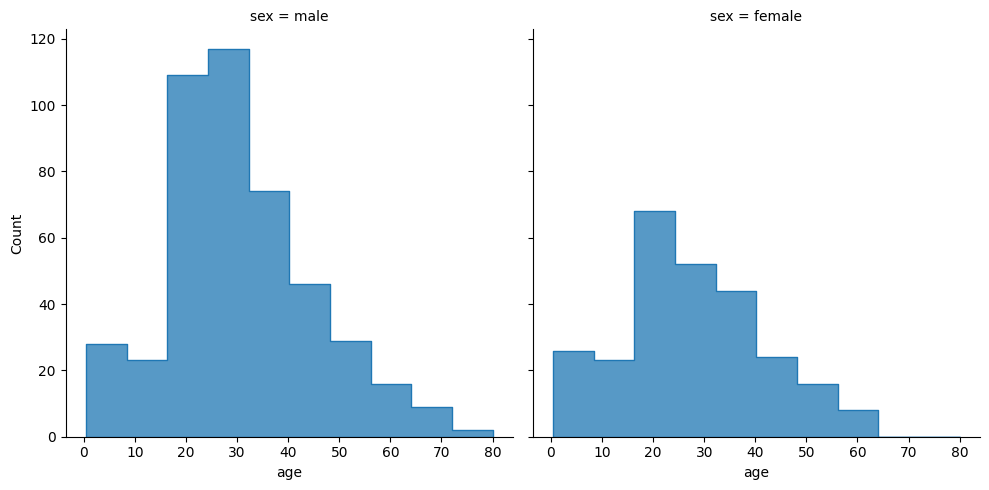

In [33]:
titanic = sns.load_dataset('titanic')

# histogram on age
print(titanic.head())
sns.displot(kind = 'hist', data = titanic, x = 'age',hue='sex',element='step',bins = 10)

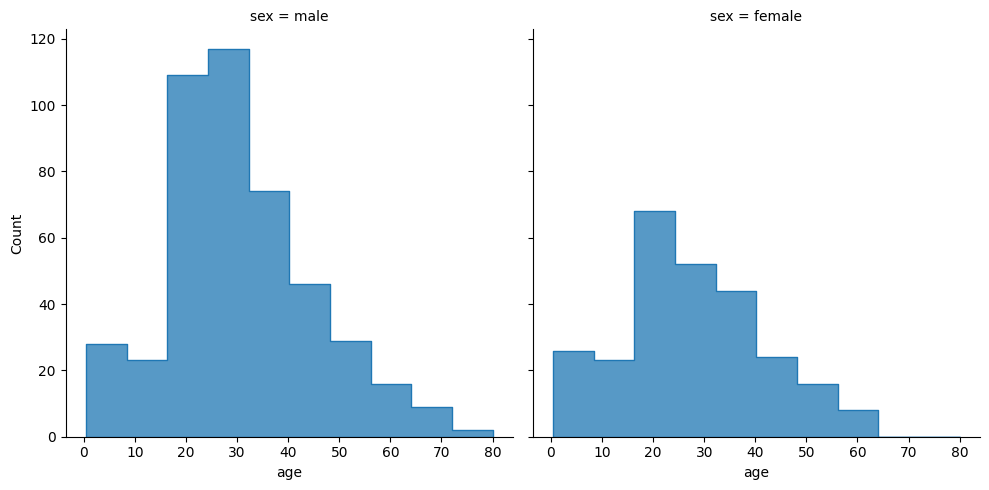

In [34]:
# facet rows and cols  -> only works in figure level fn
sns.displot(kind = 'hist', data = titanic, x = 'age',element='step',bins = 10, col = 'sex')

<Axes: xlabel='total_bill', ylabel='Density'>

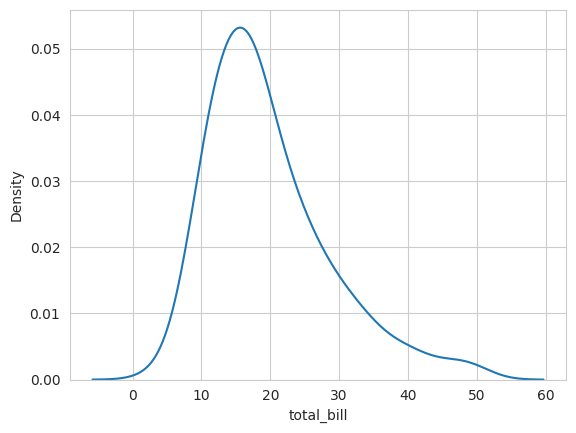

In [40]:
# kde plot -> kernel density estimation
# A KDE plot, or Kernel Density Estimation plot, isa smooth, continuous curve that visualizes the probability density of a continuous variable

tips
sns.kdeplot(data = tips, x = 'total_bill')

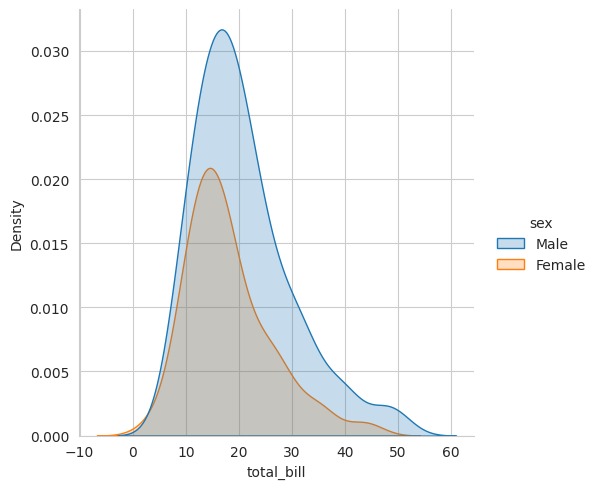

In [43]:
# hue -> fill

sns.displot(kind = 'kde',data = tips, x = 'total_bill', hue = 'sex', fill = True)

<Axes: xlabel='total_bill', ylabel='Density'>

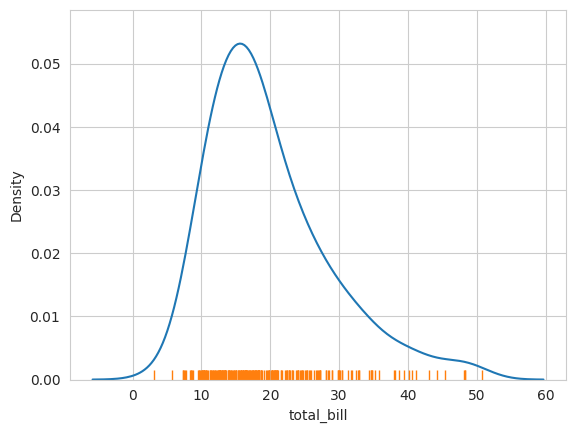

In [47]:
# Rug plot

# this generally complements other fn's

sns.kdeplot(data = tips, x = 'total_bill')
sns.rugplot(data = tips, x = 'total_bill')

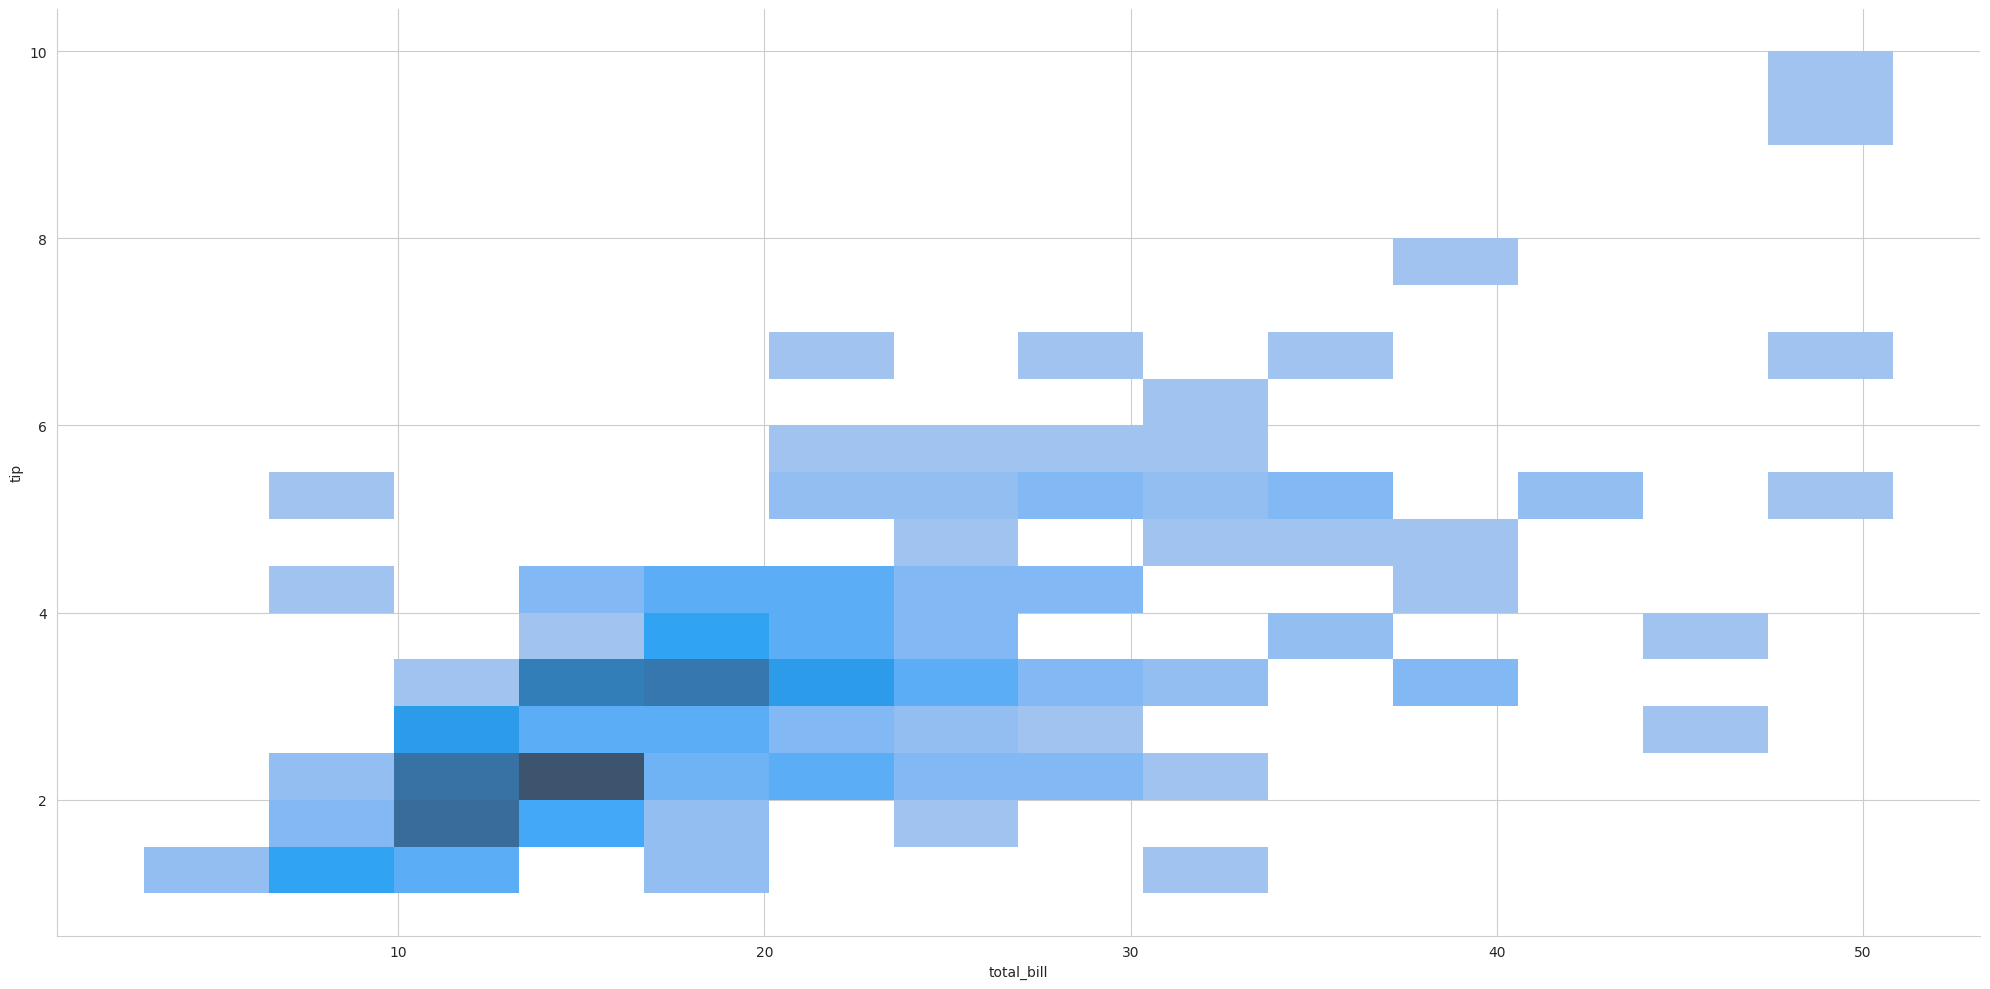

In [65]:
# bivariate histogram

# tips and total_bill histogram

sns.displot(kind = 'hist', data = tips, x = 'total_bill', y = 'tip',height= 10,aspect = 2)

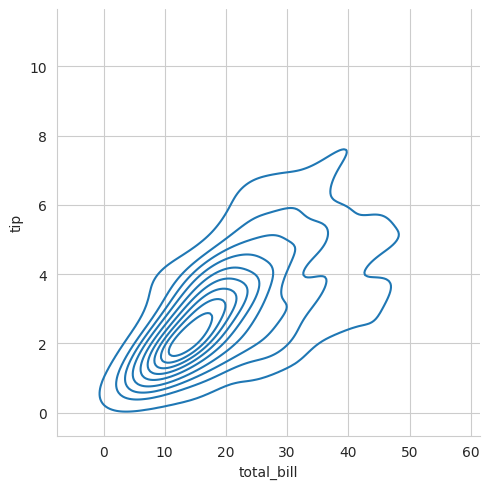

In [49]:
# bivariate kdeplot if curves are close density is more if not closer then density is lower

sns.displot(kind = 'kde', data = tips, x = 'total_bill', y = 'tip')

### 3. Matrix Plot


- Heatmap
- Clustermap

<Axes: xlabel='year', ylabel='country'>

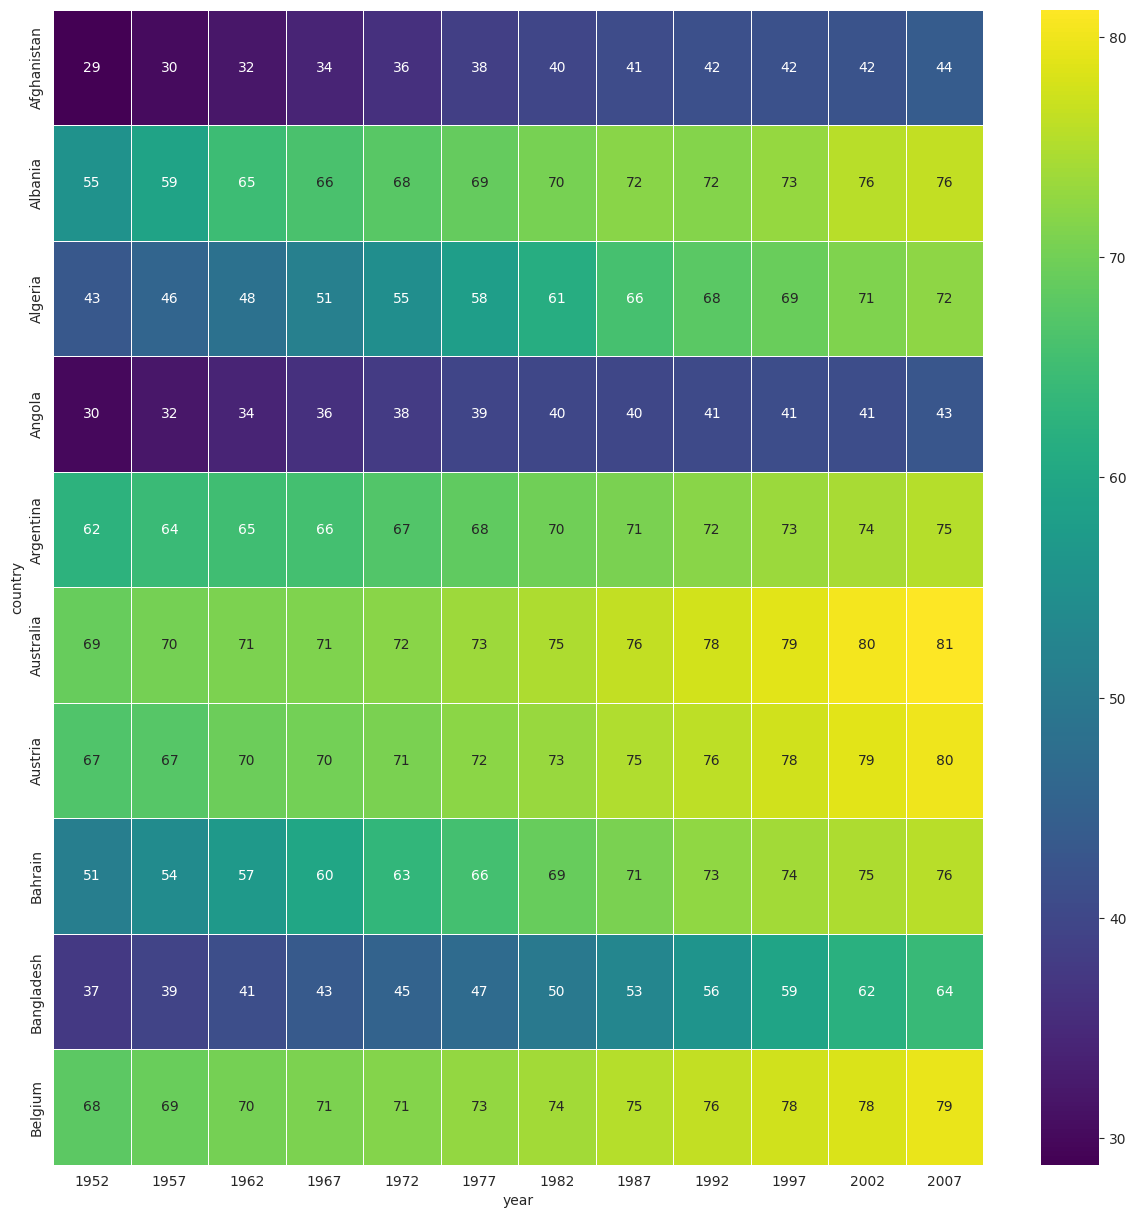

In [59]:
# heatmap -> plots rectangular data as color encoded matrix only axes level fn


gap

# countrwise each year lifeExp

# first we need to convert wide data into long data

temp = gap.pivot(index = 'country',columns='year',values = 'lifeExp').head(10)

plt.figure(figsize = (15,15)) # -> possible in axes level fn
sns.heatmap(temp,annot=True,linewidth = 0.5 , cmap = 'viridis')

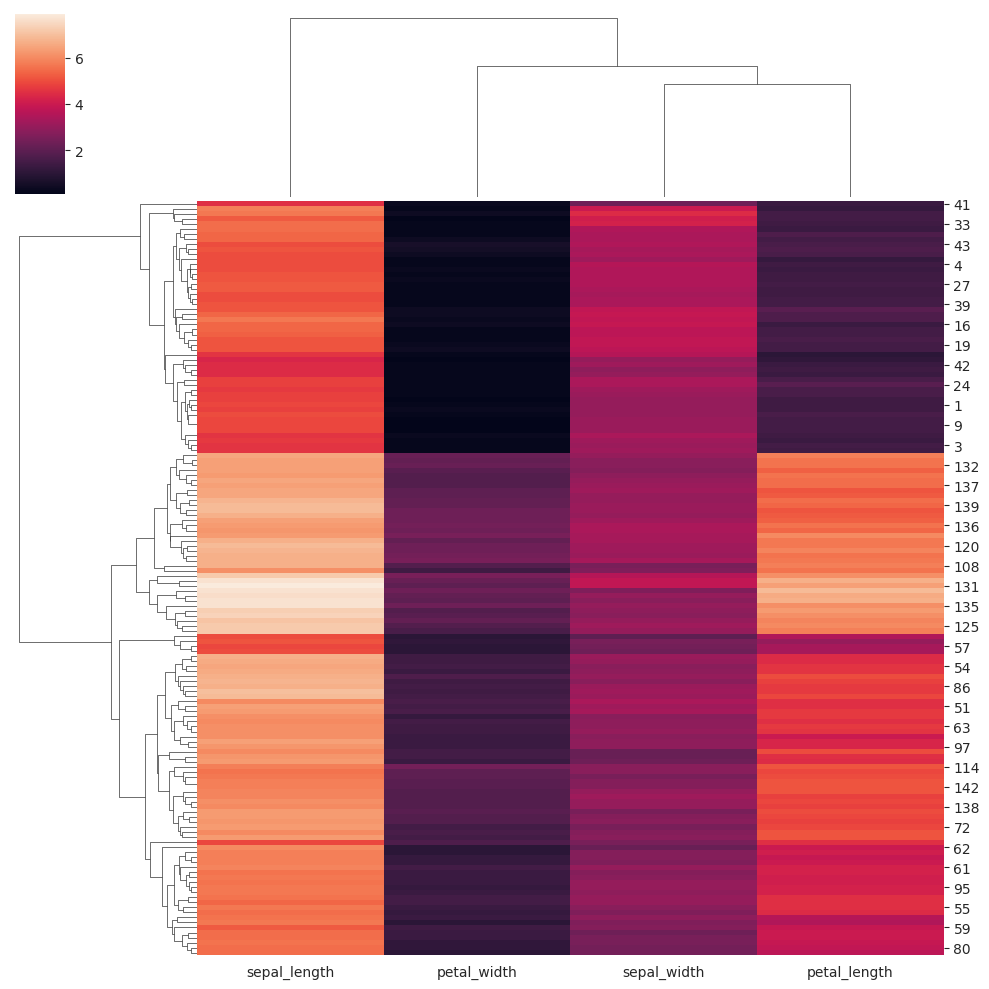

In [63]:
# clustermap

# similar to heatmap but does internaly clustering which means brings similar column together and dissimilar apart

iris = px.data.iris()

sns.clustermap(iris.iloc[:,[0,1,2,3]])